In [3]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score
from xgboost import XGBClassifier
import pickle
import os

In [4]:
# CARGO LOS DATOS
train = pd.read_csv("../data/processed/train_diabetes.csv")
test = pd.read_csv("../data/processed/test_diabetes.csv")

X_train = train.drop('Outcome', axis=1)
y_train = train['Outcome']

X_test = test.drop('Outcome', axis=1)
y_test = test['Outcome']

print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)

X_train.shape: (614, 8)
X_test.shape: (154, 8)


In [5]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Accuracy Gradient Boosting:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy Gradient Boosting: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [6]:
# XGBClassifier
xgbc = XGBClassifier(random_state=42)
xgbc.fit(X_train, y_train)
y_pred_xgbc = xgbc.predict(X_test)

print("Accuracy en test XGBClassifier:", accuracy_score(y_test, y_pred_xgbc))
print(classification_report(y_test, y_pred_xgbc))

Accuracy en test XGBClassifier: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       100
           1       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



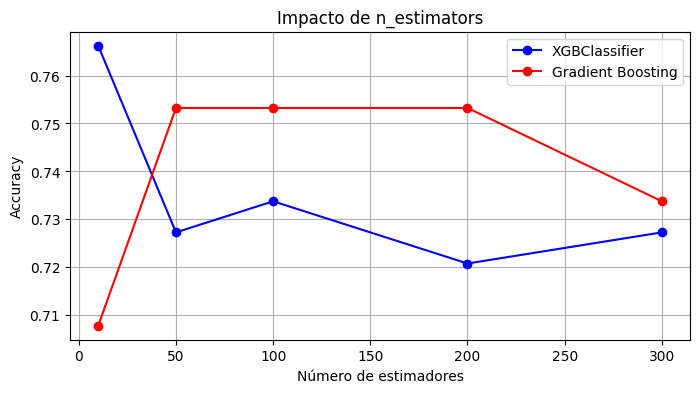

In [7]:
# Impacto de n_estimators
n_estimators = [10, 50, 100, 200, 300]
accuracy_xgbc = []
accuracy_gb = []

for n in n_estimators:
    model1 = XGBClassifier(n_estimators=n, random_state=42)
    model1.fit(X_train, y_train)
    accuracy_xgbc.append(accuracy_score(y_test, model1.predict(X_test)))
    
    model2 = GradientBoostingClassifier(n_estimators=n, random_state=42)
    model2.fit(X_train, y_train)
    accuracy_gb.append(accuracy_score(y_test, model2.predict(X_test)))

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(n_estimators, accuracy_xgbc, marker='o', label='XGBClassifier', color='blue')
plt.plot(n_estimators, accuracy_gb, marker='o', label='Gradient Boosting', color='red')
plt.title('Impacto de n_estimators')
plt.xlabel('Número de estimadores')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout
plt.show()

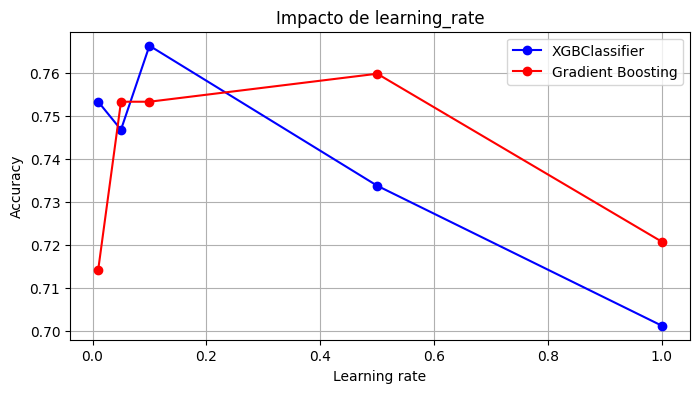

In [8]:
# Impacto de learning_rate
lr_values = [0.01, 0.05, 0.1, 0.5, 1.0]
lr_xgbc = []
lr_gb = []

for lr in lr_values:
    model1 = XGBClassifier(learning_rate=lr, random_state=42)
    model1.fit(X_train, y_train)
    lr_xgbc.append(accuracy_score(y_test, model1.predict(X_test)))
    
    model2 = GradientBoostingClassifier(learning_rate=lr, random_state=42)
    model2.fit(X_train, y_train)
    lr_gb.append(accuracy_score(y_test, model2.predict(X_test)))

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(lr_values, lr_xgbc, marker='o', label='XGBClassifier', color='blue')
plt.plot(lr_values, lr_gb, marker='o', label='Gradient Boosting', color='red')
plt.title('Impacto de learning_rate')
plt.xlabel('Learning rate')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout
plt.show()

**Optimizar con GridSearchCV**

In [9]:
config_data = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=config_data,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

print("Mejores parámetros:", grid_gb.best_params_)
print("Mejor accuracy CV:", grid_gb.best_score_)

mejor_boost = grid_gb.best_estimator_
y_pred_boost = mejor_boost.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, y_pred_boost))
print(classification_report(y_test, y_pred_boost))

Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Mejor accuracy CV: 0.7687991470078634
Accuracy en test: 0.7467532467532467
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



**Comparación de los resultados de los tres modelos**

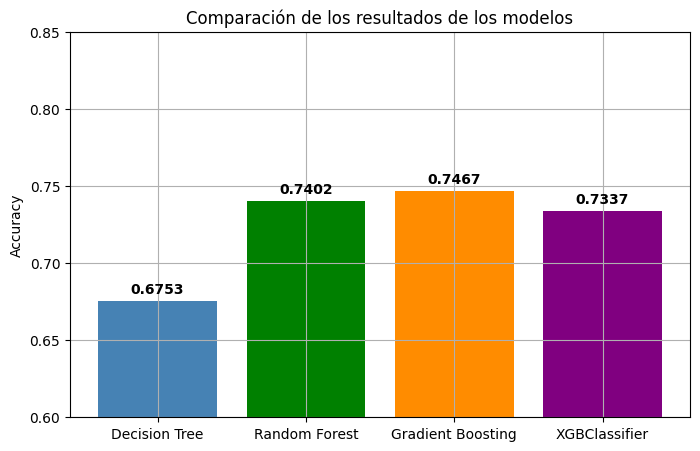

In [10]:
# TABLA COMPARATIVA
modelos = {
    'Decision Tree': 0.6753, # balanceado
    'Random Forest': 0.7402,
    'Gradient Boosting': 0.7467,
    'XGBClassifier': 0.7337
}

# Gráfico de barras
colores = ['steelblue', 'green', 'darkorange', 'purple']
plt.figure(figsize=(8, 5))
bars = plt.bar(modelos.keys(), modelos.values(), color=colores)
plt.title('Comparación de los resultados de los modelos')
plt.ylabel('Accuracy')
plt.ylim(0.60, 0.85)
for bar, val in zip(bars, modelos.values()):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.grid(True)
plt.tight_layout
plt.show()

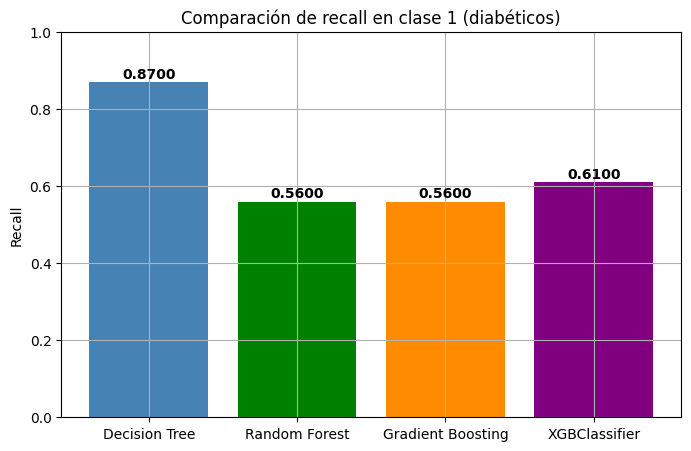

In [11]:
recalls = {
    'Decision Tree': 0.87, # balanceado
    'Random Forest': 0.56,
    'Gradient Boosting': 0.56,
    'XGBClassifier': 0.61
}

plt.figure(figsize=(8, 5))
bars = plt.bar(recalls.keys(), recalls.values(), color=colores)
plt.title('Comparación de recall en clase 1 (diabéticos)')
plt.ylabel('Recall')
plt.ylim(0, 1)
for bar, val in zip(bars, recalls.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.grid(True)
plt.tight_layout
plt.show()

In [12]:
# Cargo los modelos de proyectos anteriores
with open("../models/decision_tree_model.pkl", "rb") as f:
    dt_model = pickle.load(f)

with open("../models/random_forest_diabetes.pkl", "rb") as f:
    rf_model = pickle.load(f)

# Predicciones
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

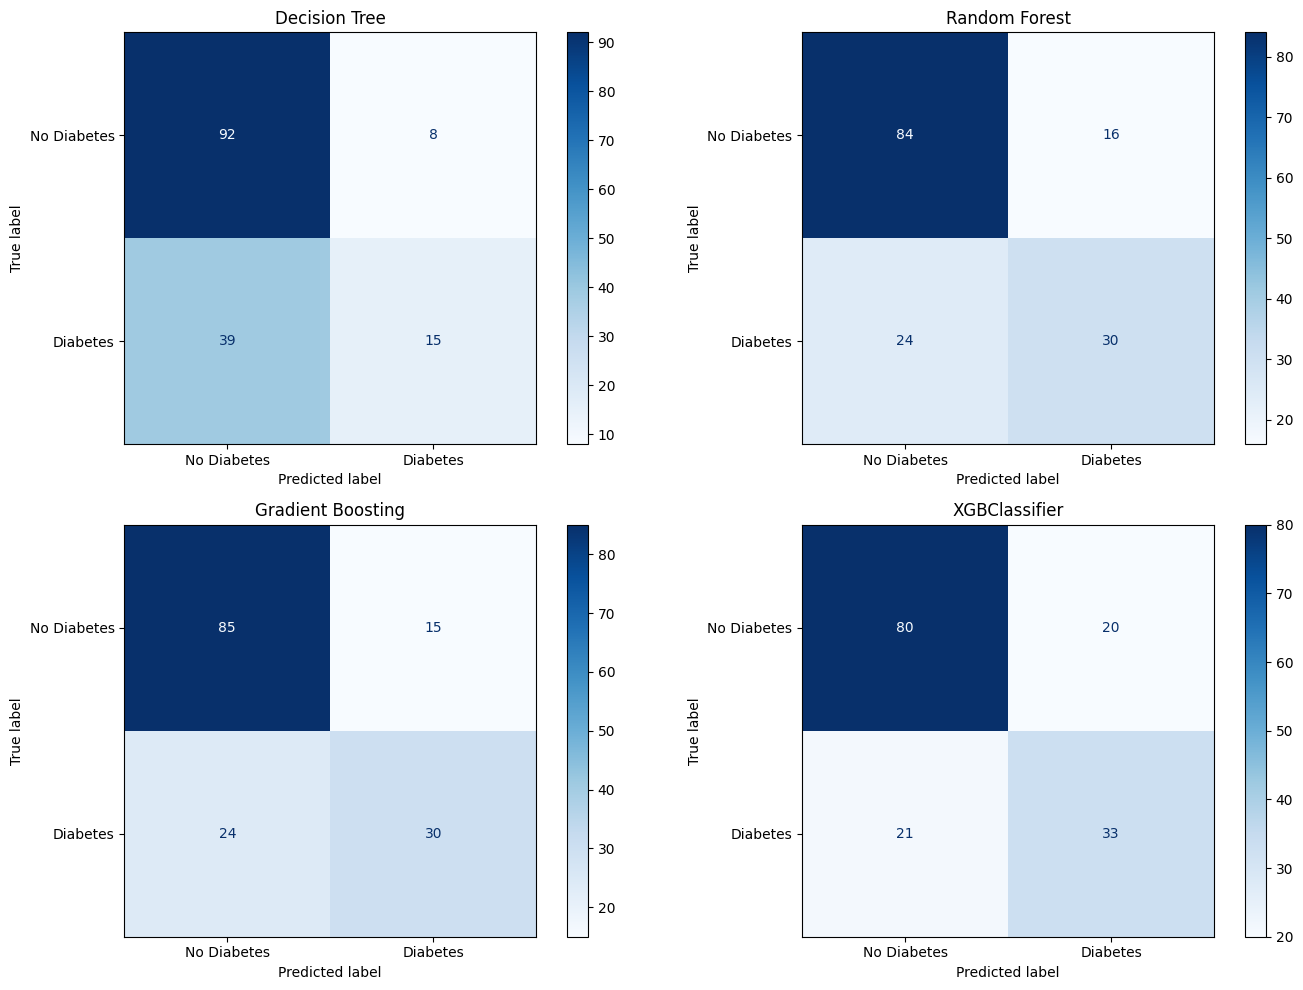

In [13]:
# MATRIZ DE CONFUSIÓN DE LOS TRES MODELOS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (nombre, y_pred) in zip(axes.flatten(), {
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_boost,
    'XGBClassifier': y_pred_xgbc
}.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No Diabetes', 'Diabetes'],
        cmap='Blues', ax=ax
    )
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

**Guardar modelo**

In [14]:
os.makedirs("../models", exist_ok=True)

with open("../models/gradient_boosting_diabetes.pkl", "wb") as f:
    pickle.dump(mejor_boost, f)

print("Modelo guardado")

Modelo guardado


**Conclusiones**

Accuracy:
- Decision Tree (sin optimizar): 0.7272
- Decision Tree (optimizado): 0.6948
- Decision Tree (balanceado): 0.6753
- Random Forest: 0.7402
- Gradient Boosting: **0.7467**
- XGBClassifier: 0.7337

Recall:
- Decision Tree (sin optimizar): 0.50
- Decision Tree (optimizado): 0.28
- Decision Tree (balanceado): **0.87**
- Random Forest: 0.56
- Gradient Boosting: 0.56
- XGBClassifier: 0.61

Los modelos que peor predicen la clase 1 son el Decision Tree optimizado (recall de 0.28) y el Decision Tree sin optimizar (recall de 0.50), seguidos por el Random Forest y el Gradient Boosting (recall de 0.56 para ambos). El que mejor la predice es el Decision Tree balanceado (recall de 0.87).

El Gradient Boosting tiene el mayor accuracy en test (0.7467). Sin embargo, me quedo con el Decision Tree balanceado porque tiene el mejor recall en la clase 1 (diabéticos). Si el objetivo es médico, hay que minimizar los falsos negativos (enfermos sin detectar).